# Advanced Topics

The setup for the modal app includes several defaults in the `settings` module that optimize inference and training for their hardware set up on modal and sometimes override [the default configuration of DeepForest](https://deepforest.readthedocs.io/en/stable/user_guide/09_configuration_file.html) [1]. This notebook extends [`treeai-example.ipynb`](treeai-example.ipynb) by covering several advanced topics:

1. **Data augmentations** to improve model generalization; we evaluate the fine-tuned model at the end so results can be compared with the baseline from `treeai-example.ipynb`
2. **Comet ML logging** to track training metrics in real time
3. **Training callbacks**, more precisely model checkpointing and early stopping
4. **HuggingFace Hub upload** to share fine-tuned model checkpoints

The TreeAI [2] data is assumed to be in the data storage volume (see the [`treeai-example.ipynb`](treeai-example.ipynb)).

## 0. Setup

Let us start with some imports:

In [ ]:
import os
import time
from os import path

import comet_ml
import matplotlib.pyplot as plt
import pandas as pd
from pytorch_lightning import callbacks, loggers

import deepforest_modal_app as dma
import treeai_utils
from deepforest_modal_app import eval_utils, plot_utils

We define the basic parameters first:

In [ ]:
# path to the Tree AI dataset
base_dir = "treeai-data/12_RGB_ObjDet_640_fL"
# to name folders in the modal volumes
dataset_id = "12_RGB_ObjDet_640_fL"

# target species
target_species = ["picea abies", "pinus sylvestris", "fagus sylvatica"]

# viz args
n_plot_imgs = 2
figwidth = plt.rcParams["figure.figsize"][0]
figheight = plt.rcParams["figure.figsize"][1]

# for reproducibility
random_state = 0

### Loading the dataset

We load the same TreeAI split used in [`treeai-example.ipynb`](treeai-example.ipynb). Images are already uploaded — the `ensure_imgs` call below is a no-op if nothing is missing:

In [ ]:
# load TreeAI dataset
train_gdf, train_img_dir, species_label_dict = treeai_utils.get_annot_gdf(
    base_dir, which="train", species=target_species
)
val_gdf, val_img_dir, _ = treeai_utils.get_annot_gdf(
    base_dir, which="val", species=target_species
)

# output fine-tuned model checkpoint
fine_tuned_filepath = path.join(dataset_id, "crown-fine-tune-aug.pl")

# ensure that annotations are strictly larger than 1 px
train_gdf = treeai_utils.ensure_gt_1px(train_gdf)
val_gdf = treeai_utils.ensure_gt_1px(val_gdf)

remote_img_dir = dataset_id
val_img_filenames = val_gdf["image_path"].unique()

In [ ]:
# ensure images are in the data volume (no-op if already uploaded)
for img_dir in [train_img_dir, val_img_dir]:
    dma.ensure_imgs(
        img_dir,
        remote_img_dir=remote_img_dir,
    )

## 1. Fine-tuning with augmentations, logger and callbacks

The fine-tuning done in [`treeai-example.ipynb`](treeai-example.ipynb) is the canonical example of how to use this set up for *serverless* training on Modal and it is designed for simplicity and pedagocial purposes. However, real-word examples will greatly benefit from further features. First, we can customize many training parameters, such as the number of workers, batch size, maximum number of epochs or hyperparameters such as the learning rate. Secondly, training will likely benefit from using data augmentations, [which are supported in DeepForest using Kornia](https://deepforest.readthedocs.io/en/stable/user_guide/11_training.html#data-augmentations). Finally, let us not forget that the `retrain_crown_model` function accepts any keyword arguments forwarded to the [PyTorch Lightning `Trainer`](https://lightning.ai/docs/pytorch/LTS/common/trainer.html) (e.g., to set up logging, callbacks...).

### 1.1 Data augmentations and training customization

Data augmentations can improve model generalization across sensors and acquisition conditions, which holds great potential towards better performance over the TreeAI dataset. Augmentations are set up as list of augmentation functions ([out of those supported by DeepForest](https://deepforest.readthedocs.io/en/stable/user_guide/11_training.html#available-augmentations)), potentially customized with their respective parameters. Then, the list should be passed as the `config_args` argument of `retrain_crown_model` under the nested "train" and "augmentations" key. We can further customize other training and validation parameters (for reference, see [the DeepForest default configuration](https://deepforest.readthedocs.io/en/stable/user_guide/09_configuration_file.html) and the customizations of this setup in the `settings` module), e.g.:

In [ ]:
# augmentation parameters
augmentations = [
    {"HorizontalFlip": {"p": 0.5}},
    {"VerticalFlip": {"p": 0.5}},
    {"Rotate": {"degrees": 45, "p": 0.5}},
    {"RandomBrightnessContrast": {"brightness": 0.2, "contrast": 0.2, "p": 0.5}},
    {"HueSaturationValue": {"hue": 0.1, "saturation": 0.1, "p": 0.5}},
    {"GaussNoise": {"std": 0.05, "p": 0.2}},
    {"GaussianBlur": {"kernel_size": (3, 3), "sigma": (0.1, 1.5), "p": 0.2}},
]
# other parameters
lr = 1e-4
val_accuracy_interval = 5

# augmentation-aware training config
config_args = {
    "train": {
        "lr": lr,
        "augmentations": augmentations,
    },
    "validation": {
        "val_accuracy_interval": val_accuracy_interval,
    },
}

Other customizations can directly be passed as keyword arguments of `retrain_crown_model`, which will be forwarded to underlying [PyTorch Lightning instantiation](https://lightning.ai/docs/pytorch/stable/common/trainer.html#init), e.g., the maximum number of training epochs

In [ ]:
max_epochs = 50

### 1.2 Logging

Amongst the PyTorch Lightning features that can be customized by passing keyword arguments to `retrain_crown_model`, logging is key to track training progress and debug potential issues. We can pass [any logger supported by PyTorch Lightning](https://lightning.ai/docs/pytorch/stable/api_references.html#loggers) (e.g., Comet, Weights & Biases, MLflow...) as the `logger` argument of `retrain_crown_model`. In this example, we will set up a Comet ML logger (note that we need the `COMET_ML_API_KEY` environment variable to be set for this to work):

In [ ]:
# for Comet ML
comet_ml_api_key = os.getenv("COMET_ML_API_KEY", "")
comet_ml_project_name = "deepforest-modal-app"
comet_ml_workspace = "martibosch"

# logger parameters
comet_logger_kwargs = {
    "api_key": comet_ml_api_key,
    "project": comet_ml_project_name,
    "workspace": comet_ml_workspace,
}

# logger object
comet_logger = loggers.CometLogger(**comet_logger_kwargs)

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/martibosch/deepforest-modal-app/5b6388e13a72430198227f0bb3f4ceed

COMET WARNING: Unknown error exporting current conda environment
COMET WARNING: Unknown error retrieving Conda package as an explicit file
COMET WARNING: Unknown error retrieving Conda information


## 1.3 Callbacks

Callbacks are another powerful feature of PyTorch Lightning that can be used to customize the training loop. For example, we can set up a model checkpoint callback to save the best model weights during training and an early stopping callback to stop training if the validation loss does not improve for a certain number of epochs. Both callbacks are configured by defining their parameters and then instantiating the respective callback objects, which can then be passed as a list to the `callbacks` argument of `retrain_crown_model`:

In [ ]:
# callback parameters
callback_monitor = "val_loss"
callback_mode = "min"

# checkpoint callback
checkpoint_dir = path.join(dma.settings.MODELS_DIR, dataset_id, "train-checkpoints")
every_n_epochs = 10
checkpoint_callback_kwargs = {
    "dirpath": checkpoint_dir,
    "monitor": callback_monitor,
    "mode": callback_mode,
    "save_top_k": 1,
    "filename": "crown-aug-{epoch:02d}-{box_recall:.2f}",
    "every_n_epochs": every_n_epochs,
}

# early stopping callback
stop_min_delta = 0.002
stop_patience = 5
stop_callback_kwargs = {
    "monitor": callback_monitor,
    "min_delta": stop_min_delta,
    "patience": stop_patience,
    "verbose": True,
    "mode": callback_mode,
}

# callback objects
checkpoint_callback = callbacks.ModelCheckpoint(**checkpoint_callback_kwargs)
stop_callback = callbacks.EarlyStopping(**stop_callback_kwargs)

## 1.4 Putting it all together: training the fine-tuned model with augmentations, logger and callbacks

We can now pass the custom configuration including the augmentations through the `config_args` argument and the other PyTorch Lightning trainer arguments (logger, callbacks, max epochs) to the `retrain_crown_model` function:

In [ ]:
with dma.app.run():
    _start = time.perf_counter()
    dma.retrain_crown_model.remote(
        train_gdf.assign(**{"label": "Tree"}),
        remote_img_dir,
        test_df=val_gdf.assign(**{"label": "Tree"}),
        config_args=config_args,
        dst_filepath=fine_tuned_filepath,
        logger=comet_logger,
        max_epochs=max_epochs,
        callbacks=[checkpoint_callback, stop_callback],
    )
    print(
        "Fine-tuned crown model training completed in "
        f"{time.perf_counter() - _start:.1f}s"
    )
    comet_logger.experiment.end()

COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : thoughtless_estuary_887
COMET INFO:     url                   : https://www.comet.com/martibosch/deepforest-modal-app/5b6388e13a72430198227f0bb3f4ceed
COMET INFO:   Others:
COMET INFO:     Created from : pytorch-lightning
COMET INFO:   Uploads:
COMET INFO:     environment details      : 1
COMET INFO:     filename                 : 1
COMET INFO:     git metadata             : 1
COMET INFO:     git-patch (uncompressed) : 1 (2.79 MB)
COMET INFO:     installed packages       : 1
COMET INFO:     notebook                 : 1
COMET INFO:     os packages              : 1
COMET INFO:     source_code              : 1
COMET INFO: 


Fine-tuned crown model training completed in 1651.0s


We can now retrieve the training metrics from Comet ML, e.g., the evolution of the validation loss across epochs:

<Axes: xlabel='step'>

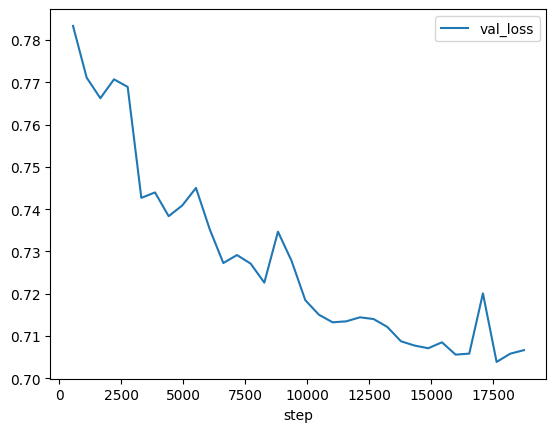

In [ ]:
experiment = comet_ml.API(api_key=comet_ml_api_key).get_experiment(
    project_name=comet_ml_project_name,
    workspace=comet_ml_workspace,
    experiment=comet_logger.experiment.get_key(),
)

plot_utils.plot_metric(experiment, "val_loss", kind="line")

## 2. Inference and evaluation

We run inference with the augmentation-trained model and compute precision and recall on the validation set. These numbers can be directly compared with those obtained in [`treeai-example.ipynb`](treeai-example.ipynb) (same data, same parameters, no augmentations) to quantify the benefit of the augmentation strategy:

In [ ]:
with dma.app.run():
    _start = time.perf_counter()
    aug_pred_gdf = dma.predict.remote(
        img_filenames=val_img_filenames,
        remote_img_dir=remote_img_dir,
        checkpoint_filepath=fine_tuned_filepath,
    )
    print(
        f"Fine-tuned inference predicted {len(val_img_filenames)} tiles in "
        f"{time.perf_counter() - _start:.1f}s"
    )

Fine-tuned inference predicted 145 tiles in 28.7s


/home/martibosch/libraries/deepforest-modal-app/.pixi/envs/user-guide/lib/python3.12/site-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/home/martibosch/libraries/deepforest-modal-app/.pixi/envs/user-guide/lib/python3.12/site-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


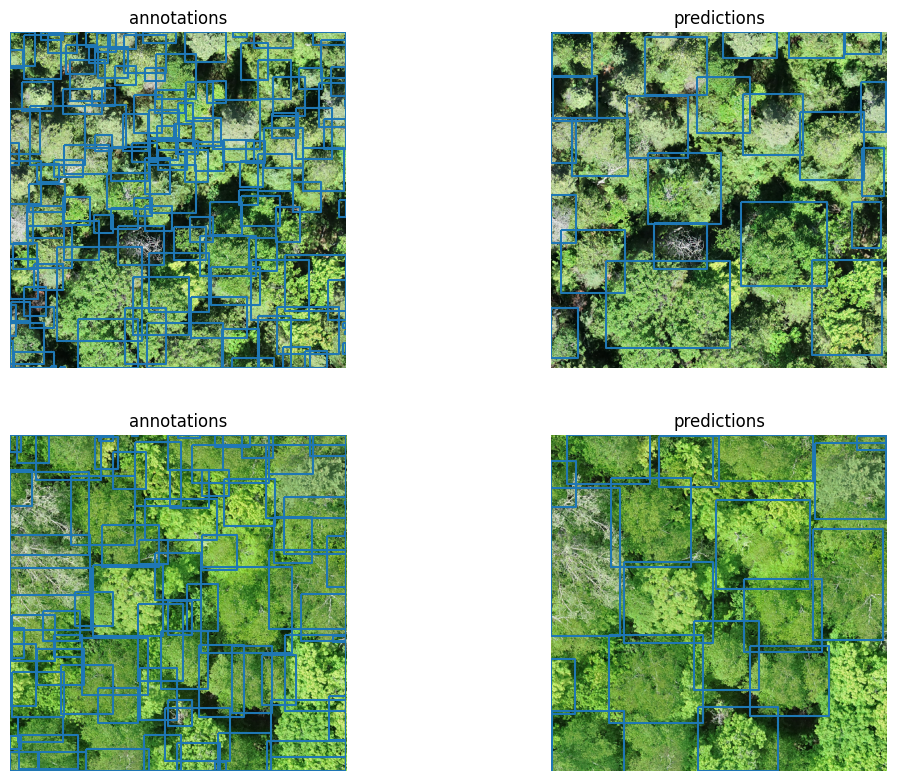

In [ ]:
plot_img_filenames = pd.Series(val_img_filenames).sample(
    n_plot_imgs, random_state=random_state
)
# TODO: fix the need to set the label as tree to avoid single-species detection issues
crown_annot_gdf = val_gdf.assign(**{"label": "Tree"})
fig = plot_utils.plot_annot_vs_pred(
    aug_pred_gdf[aug_pred_gdf["image_path"].isin(plot_img_filenames)],
    crown_annot_gdf[crown_annot_gdf["image_path"].isin(plot_img_filenames)],
    # val_gdf[val_gdf["image_path"].isin(plot_img_filenames)],
    val_img_dir,
    plot_pred_kwargs={"legend": False, "column": None},
    plot_annot_kwargs={"legend": False, "column": None},
)

In [ ]:
eval_iou_threshold = 0.4  # DeepForest default
aug_eval_results = eval_utils.evaluate_geometry(
    aug_pred_gdf, crown_annot_gdf, iou_threshold=eval_iou_threshold
)

box_precision = float(aug_eval_results["box_precision"])
box_recall = float(aug_eval_results["box_recall"])
box_f1 = (
    0.0
    if (box_precision + box_recall) == 0
    else 2 * box_precision * box_recall / (box_precision + box_recall)
)
print(
    f"Evaluation metrics at IoU >= {eval_iou_threshold:.2f}\n"
    f"box_precision: {box_precision:.4f}\n"
    f"box_recall:    {box_recall:.4f}\n"
    f"box_f1:        {box_f1:.4f}"
)

Evaluation metrics at IoU >= 0.40
box_precision: 0.6321
box_recall:    0.1831
box_f1:        0.2840


When compared to the pre-trained DeepForest model (see the `treeai-example.ipynb` notebook), there is a very small improvement in precision and more noticeable improvements in recall and F1-score (from respectively 0.6284, 0.1367 and 0.2245 in the pre-trained model).

## 3. Upload fine-tuned model to HuggingFace Hub

We can push the fine-tuned checkpoint to the HuggingFace Hub with `checkpoint_to_hf_hub`. This creates (or updates) a repository at `https://huggingface.co/<username>/<hf_hub_repo_id>` and uploads the model card alongside the weights:

In [ ]:
# for HuggingFace Hub
hf_hub_repo_id = "deepforest-treeai"
model_name = "deepforest-treeai"
model_tags = ["object-detection", "retinanet"]
with dma.app.run():
    dma.checkpoint_to_hf_hub.remote(
        fine_tuned_filepath,
        hf_hub_repo_id,
        model_card_kwargs=dict(
            tags=model_tags,
            model_name=model_name,
        ),
    )

## References

1. Weinstein, B. G., Marconi, S., Aubry‐Kientz, M., Vincent, G., Senyondo, H., & White, E. P. (2020). DeepForest: A Python package for RGB deep learning tree crown delineation. Methods in Ecology and Evolution, 11(12), 1743-1751.
2. Beloiu Schwenke, M., Xia, Z., Novoselova, I., Gessler, A., Kattenborn, T., Mosig, C., Puliti, S., Waser, L., Rehush, N., Cheng, Y., Xinliang, L., Griess, V. C., & Mokroš, M. (2025). TreeAI Global Initiative - Advancing tree species identification from aerial images with deep learning (TreeAI.V1.2) [Data set]. Zenodo. https://doi.org/10.5281/zenodo.15351054